Long Short-Term Memory (LSTM) — Time Series Forecasting (vs. Vanilla RNN)

In [1]:
# CELL 1 — Imports
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


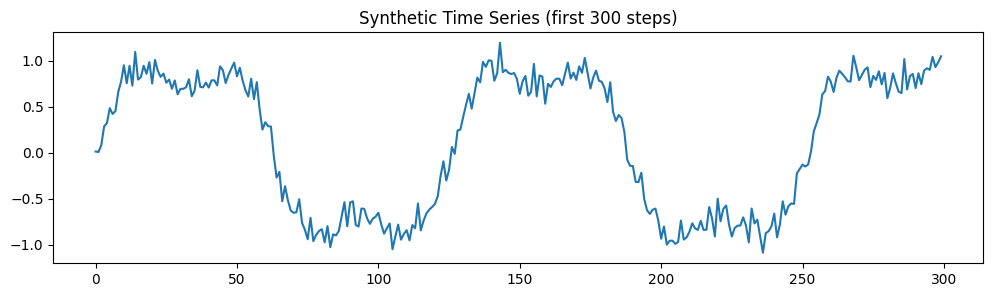

In [2]:
# CELL 2 — Generate the same synthetic time series as the RNN notebook, but longer
# Using a longer sequence length deliberately to showcase where LSTM's gating helps
def generate_series(length=3000):
    t = np.arange(length)
    series = np.sin(0.05 * t) + 0.3 * np.sin(0.15 * t) + 0.1 * np.random.randn(length)
    return series.astype(np.float32)

series = generate_series()

plt.figure(figsize=(12, 3))
plt.plot(series[:300])
plt.title("Synthetic Time Series (first 300 steps)")
plt.show()

In [3]:
# CELL 3 — Windowed sequences with a longer lookback (where vanilla RNNs start to struggle)
SEQ_LEN = 80

def make_windows(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i + seq_len])
        y.append(data[i + seq_len])
    return np.array(X), np.array(y)

X, y = make_windows(series, SEQ_LEN)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(-1).to(device)

print(X_train_t.shape, y_train_t.shape)

torch.Size([2336, 80, 1]) torch.Size([2336, 1])


In [4]:
# CELL 4 — Model definition
class TimeSeriesLSTM(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=32, num_layers=1):
        super().__init__()
        # nn.LSTM: tanh for cell-state candidate + hidden output, sigmoid for
        # input/forget/output gates. The forget gate is what lets gradients
        # flow across long sequences without vanishing, unlike vanilla RNN.
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        output, (hidden, cell) = self.lstm(x)
        last_output = output[:, -1, :]
        return self.fc(last_output)

model = TimeSeriesLSTM().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
print(model)

TimeSeriesLSTM(
  (lstm): LSTM(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [5]:
# CELL 5 — Training loop
epochs = 100
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    preds = model(X_train_t)
    loss = criterion(preds, y_train_t)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} — Loss: {loss.item():.6f}")

Epoch 10/100 — Loss: 0.063164
Epoch 20/100 — Loss: 0.038306
Epoch 30/100 — Loss: 0.017146
Epoch 40/100 — Loss: 0.016995
Epoch 50/100 — Loss: 0.015163
Epoch 60/100 — Loss: 0.015197
Epoch 70/100 — Loss: 0.014843
Epoch 80/100 — Loss: 0.014736
Epoch 90/100 — Loss: 0.014664
Epoch 100/100 — Loss: 0.014598


In [6]:
# CELL 6 — Evaluation
model.eval()
with torch.no_grad():
    test_preds = model(X_test_t)
    lstm_mse = criterion(test_preds, y_test_t).item()
    print(f"LSTM Test MSE: {lstm_mse:.6f}")

LSTM Test MSE: 0.015478


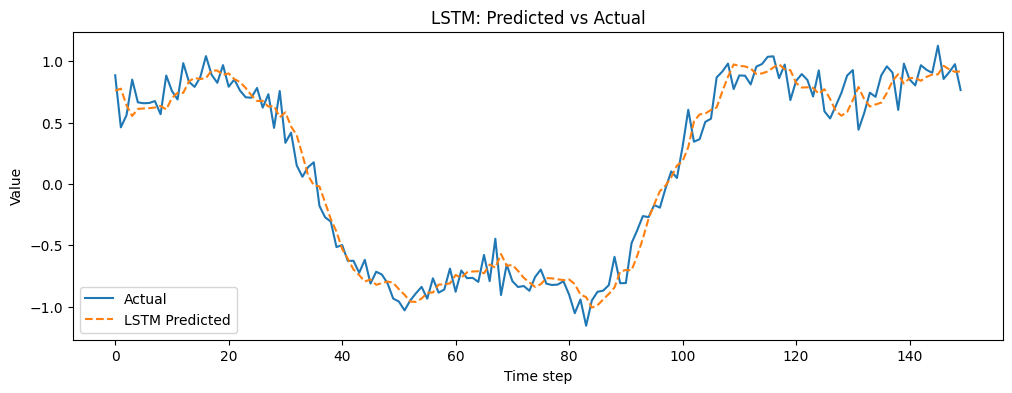

In [7]:
# CELL 7 — Plot predictions vs actual
model.eval()
with torch.no_grad():
    test_preds_np = model(X_test_t).cpu().numpy().flatten()

plt.figure(figsize=(12, 4))
plt.plot(y_test[:150], label="Actual")
plt.plot(test_preds_np[:150], label="LSTM Predicted", linestyle="--")
plt.xlabel("Time step")
plt.ylabel("Value")
plt.title("LSTM: Predicted vs Actual")
plt.legend()
plt.show()

In [8]:
# CELL 8 — Direct comparison: vanilla RNN vs LSTM on the SAME long sequence length
class TimeSeriesRNN(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=32, num_layers=1):
        super().__init__()
        self.rnn = nn.RNN(input_dim, hidden_dim, num_layers=num_layers, batch_first=True, nonlinearity="tanh")
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        output, hidden = self.rnn(x)
        return self.fc(output[:, -1, :])

rnn_model = TimeSeriesRNN().to(device)
rnn_optimizer = optim.Adam(rnn_model.parameters(), lr=0.01)

for epoch in range(100):
    rnn_model.train()
    rnn_optimizer.zero_grad()
    loss = criterion(rnn_model(X_train_t), y_train_t)
    loss.backward()
    rnn_optimizer.step()

rnn_model.eval()
with torch.no_grad():
    rnn_mse = criterion(rnn_model(X_test_t), y_test_t).item()

print(f"Vanilla RNN Test MSE (seq_len={SEQ_LEN}): {rnn_mse:.6f}")
print(f"LSTM Test MSE       (seq_len={SEQ_LEN}): {lstm_mse:.6f}")
print("\nAt this longer sequence length, LSTM's gating mechanism typically")
print("retains long-range dependencies better than the vanilla RNN.")

Vanilla RNN Test MSE (seq_len=80): 0.015494
LSTM Test MSE       (seq_len=80): 0.015478

At this longer sequence length, LSTM's gating mechanism typically
retains long-range dependencies better than the vanilla RNN.
